## 1. Introduction

i.

1 example: ```RecSys (Netlfix, Spotify)``` algorithms analyze your surfing history, correspond it to other users, so it helps you to find relevant content faster.

2 example: ```Antispam``` classify e-mail as spam or not, it prevents users from fishing cases and also from trash e-mails.

3 example: ```Navigation``` analyze the big amount of data from users coordinates and geo-location to help optimizing the lenght of thier path, saves time or fuel of vehicles.

4 example: ```Voice assistants``` natural language recognition for understanding user commands, it helps to control your home, set timers, or search for information when your hands are busy or if the user has visual or motor limitations.

5 example: ```Bank scoring or Fraud monitoring``` models instantly assess the probability that a transaction was not made by you or analyze your loan application. It helps to reduce financial risks.

ii.
### Supervised learning

Classification tasks:

2 (predict whether a client returns a loan, binary classification),

4 (choose what medicine out of available a patient should take, multiclass),

5 (choose segment of clients for a promo communication, binary),

6 (recognition of defective products on the production line (based on photo scans), binary),

8 (search sites for input text query, it can be binary classification like user open or not site, but it's definetly ranking task, it wasn't mention in Intro part in some reason)

10 (detect anomaly in site traffic, binary)


Regression tasks: 

1 (predict house price), 

3 (predict when a patient needs to take medicine),

7 (decide how to place products on a shelf in a store)


### Unsupervised learning

Clustering:  

5 (choose segment of clients for a promo communication),

9 (split customers of a store into segments to understand differences of their behavior)

Assosiation:

9 (split customers of a store into segments to understand differences of their behavior),
7 (decide how to place products on a shelf, model should find tissue between products to better combination on shelf)

Dimensionality reduction (here it's mostly helpful method for clustering, and need to reduce big num of features without losses of informativity of them, just highlight and leave thr most valuable one): 

5 (choose segment of clients for a promo communication),

9 (split customers of a store into segments to understand differences of their behavior)


For my examples of applying ML methods: RecSys - ranking task (model decide which content should be shown firstly), Antispam - binary classification (good or trash e-mail), Navigation - regeresssion (model predict optimal time to spend on the path), Voice asssistan - multiclass classification, seq2seq (extract of context labels and audio to text transformation), Bank scoring or Fraud monitoring - binary classification (pay back or not loan, bad or not transaction).


iii.

In multiclass classification, each sample is assigned to exactly one class out of three or more mutually exclusive categories. In contrast, multilabel classification allows a sample to belong to multiple labels simultaneously, as the classes are not mutually exclusive.

iV. 

The house prices example is a regression problem because the target variable (price) is a continuous numerical value, not a discrete category. It is possible to reduce a regression problem to classification by discretizing the target into bins or intervals (e.g., "low," "medium," "high" price ranges), effectively turning it into a multiclass task. However, this approach sacrifices prediction precision, introduces arbitrary boundary effects, and may lead to imbalanced classes or loss of useful information.

## 2. Introduction to Data Analysis

i.

In [1]:
import pandas as pd
import numpy as np
import sklearn
import scipy
import statsmodels
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

pd.options.display.float_format = '{:.2f}'.format

ii.

In [2]:
train = pd.read_json('data/train.json')

iii.

In [3]:
train.shape

(49352, 15)

In [4]:
train

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.00,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.71,7170325,-73.95,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.00,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.75,7092344,-73.97,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.00,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.76,7158677,-73.96,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.50,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.71,7211212,-73.94,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.00,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.74,7225292,-73.97,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.00,3,92bbbf38baadfde0576fc496bd41749c,2016-04-05 03:58:33,There is 700 square feet of recently renovated...,W 171 Street,"[Elevator, Dishwasher, Hardwood Floors]",40.84,6824800,-73.94,a61e21da3ba18c7a3d54cfdcc247e1f8,[https://photos.renthop.com/2/6824800_0682be16...,2800,620 W 171 Street,low
124002,1.00,2,5565db9b7cba3603834c4aa6f2950960,2016-04-02 02:25:31,"2 bedroom apartment with updated kitchen, rece...",Broadway,"[Common Outdoor Space, Cats Allowed, Dogs Allo...",40.82,6813268,-73.96,8f90e5e10e8a2d7cf997f016d89230eb,[https://photos.renthop.com/2/6813268_1e6fcc32...,2395,3333 Broadway,medium
124004,1.00,1,67997a128056ee1ed7d046bbb856e3c7,2016-04-26 05:42:03,No Brokers Fee * Never Lived 1 Bedroom 1 Bathr...,210 Brighton 15th St,"[Dining Room, Elevator, Pre-War, Laundry in Bu...",40.58,6927093,-73.96,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/6927093_93a52104...,1850,210 Brighton 15th St,medium
124008,1.00,2,3c0574a740154806c18bdf1fddd3d966,2016-04-19 02:47:33,Wonderful Bright Chelsea 2 Bedroom apartment o...,West 21st Street,"[Pre-War, Laundry in Unit, Dishwasher, No Fee,...",40.74,6892816,-74.00,c3cd45f4381ac371507090e9ffabea80,[https://photos.renthop.com/2/6892816_1a8d087a...,4195,350 West 21st Street,medium


iv.

In [5]:
train.columns

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')

Answer: price is a target

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [7]:
train.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00,49352.00,49352.00,49352.00,49352.00,49352.00
mean,1.21,1.54,40.74,7024054.66,-73.96,3830.17
std,0.50,1.12,0.64,126274.61,1.18,22066.87
min,0.00,0.00,0.00,6811957.00,-118.27,43.00
25%,1.00,1.00,40.73,6915887.50,-73.99,2500.00
50%,1.00,1.00,40.75,7021070.50,-73.98,3150.00
75%,1.00,2.00,40.77,7128733.25,-73.95,4100.00
max,10.00,8.00,44.88,7753784.00,0.00,4490000.00


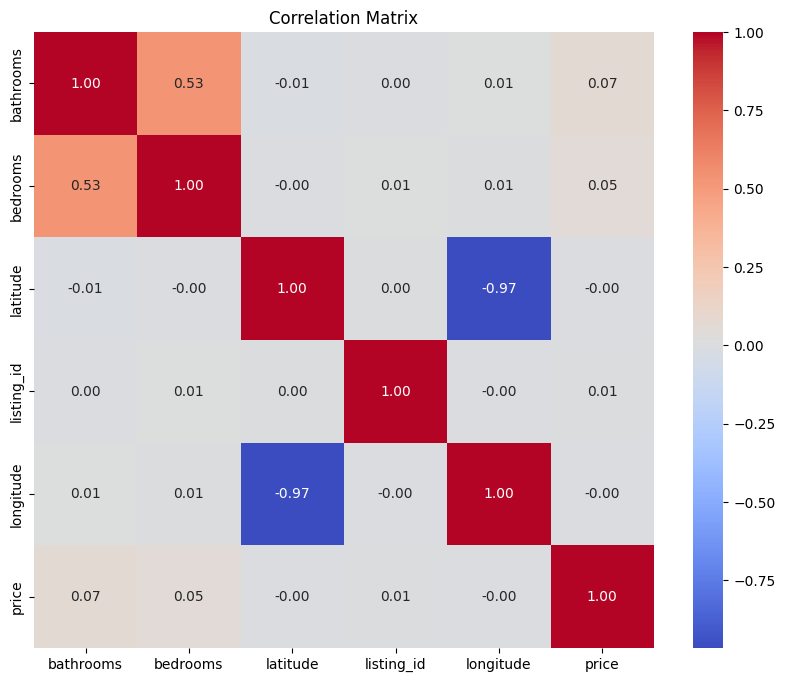

In [8]:
corr_matrix = train.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [9]:
train.isnull().sum()

bathrooms          0
bedrooms           0
building_id        0
created            0
description        0
display_address    0
features           0
latitude           0
listing_id         0
longitude          0
manager_id         0
photos             0
price              0
street_address     0
interest_level     0
dtype: int64

Answer: There're no empty columns

#### Summary of EDA

Average price is higher than median (3830.17 > 3150.00), it means there're several appartment which is "pull" average value higher. Also we've outlier in price - 4490000.00, set of 75% appratments cost no more than 4100.00, maybe this 4490000.00 value is misprint or luxury living house.

An average of 1.21 bathrooms and 1.54 bedrooms - a typical apartment is a studio or one-bedroom. A maximum of 10 bathrooms and 8 bedrooms - penthouses or mansions. 

The spread across the territory is small (std 0.64 and 1.18) - all objects in one area.

In [10]:
features = ['bathrooms', 'bedrooms', 'interest_level']
target = ['price']

df = train[features + target].copy()
df

,bathrooms,bedrooms,interest_level,price
4,1.00,1,medium,2400
6,1.00,2,low,3800
9,1.00,2,medium,3495
10,1.50,3,medium,3000
15,1.00,0,low,2795
...,...,...,...,...
124000,1.00,3,low,2800
124002,1.00,2,medium,2395
124004,1.00,1,medium,1850
124008,1.00,2,medium,4195


## 3. Statistical Data Analysis

iii. Target analysis

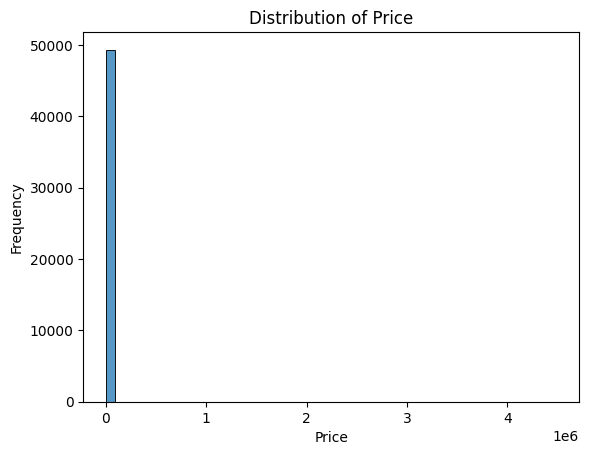

In [11]:
sns.histplot(df['price'], bins=50)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

Because of outliers we have stretching on x axis, the most part of price is close to 0, but abnormal values do this plot not clear for understanding of data distribution.

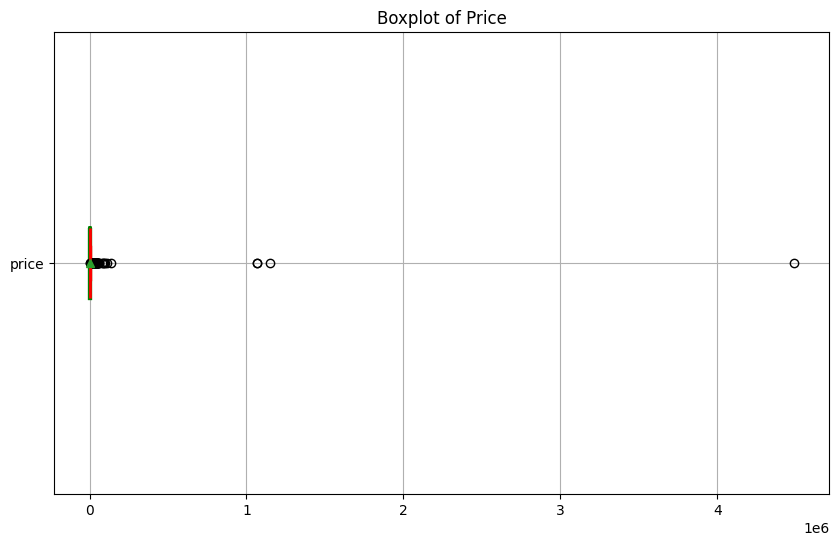

In [12]:
box_props = {
    'showmeans': True,
    'boxprops': {
        'color': 'green',
        'linewidth': 3
    },
    'medianprops': {
        'color': 'red',
        'linewidth': 2
    },
    'whiskerprops': {
        'color': 'red',
        'linewidth': 1
    },
    'capprops': {
        'color': 'red',
        'linewidth': 1
    },
}

plt.figure(figsize=(10, 6))
df.boxplot(
    column='price',
    vert=False,
    showfliers=True,
    **box_props
)
plt.title('Boxplot of Price')
plt.show()

There're at least 3 outliers

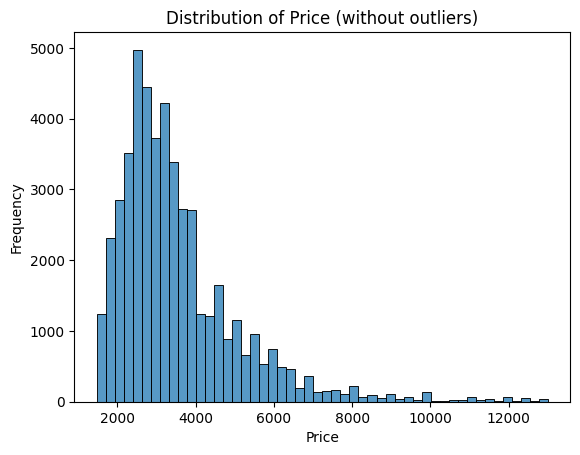

In [13]:
lower_boundary = df['price'].quantile(0.01)
upper_boundary = df['price'].quantile(0.99)

df_clean = df[df['price'].between(lower_boundary, upper_boundary)].copy()

sns.histplot(df_clean['price'], bins=50)
plt.title('Distribution of Price (without outliers)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

After removing outliers, the histogram reveals a right-skewed distribution typical for rental price data. The majority of apartments are concentrated in the 2000-4000 range, with a peak around 2500-3000.
The long tail extending to the right indicates fewer high-end luxury apartments priced above 6000. This positive skewness suggests that while most rentals are affordable, there is a small segment of premium properties commanding significantly higher prices.

iv. Characteristics Analysis

In [14]:
df_clean['interest_level'].unique()

array(['medium', 'low', 'high'], dtype=object)

In [15]:
df_clean['interest_level'].value_counts()

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

In [16]:
map_interest = {'low': 0, 'medium': 1, 'high': 2}
df_clean['interest_level'] = df_clean['interest_level'].map(map_interest)

In [17]:
df_clean['interest_level'].value_counts()

interest_level
0    33697
1    11116
2     3566
Name: count, dtype: int64

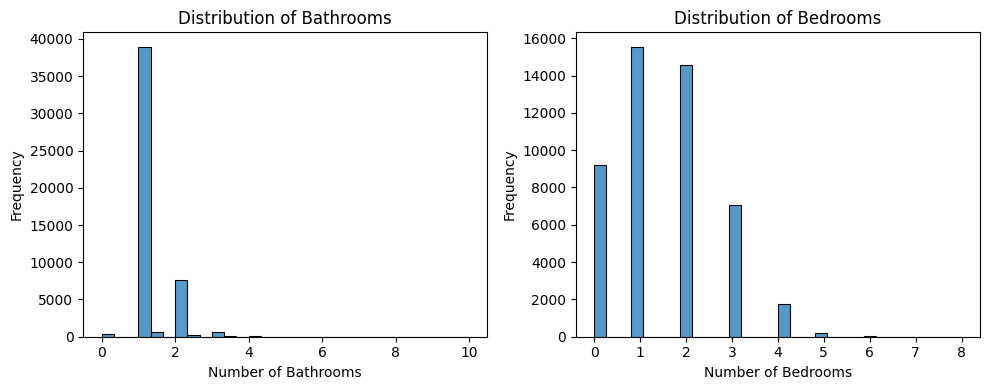

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df_clean['bathrooms'], bins=30, ax=ax[0])
sns.histplot(df_clean['bedrooms'], bins=30, ax=ax[1])
ax[0].set_title('Distribution of Bathrooms')
ax[1].set_title('Distribution of Bedrooms')
ax[0].set_xlabel('Number of Bathrooms')
ax[1].set_xlabel('Number of Bedrooms')
ax[0].set_ylabel('Frequency')
ax[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

As we can see above, there're no any outliers for this features

v. Complex analysis

In [19]:
cor_matrix = df_clean.corr()
cor_matrix

,bathrooms,bedrooms,interest_level,price
bathrooms,1.00,0.52,-0.06,0.67
bedrooms,0.52,1.00,0.05,0.55
interest_level,-0.06,0.05,1.00,-0.20
price,0.67,0.55,-0.20,1.00


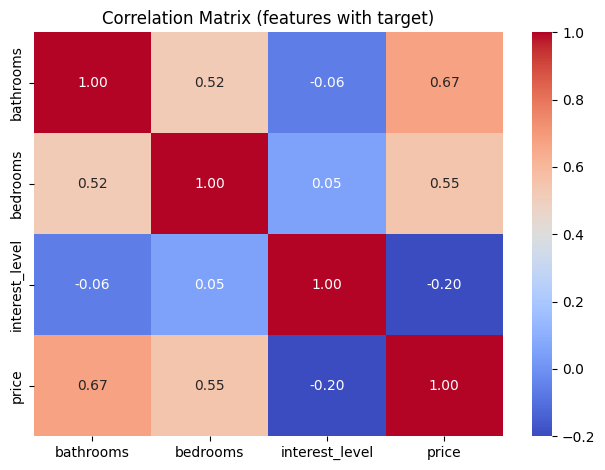

In [20]:
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (features with target)')
plt.tight_layout()
plt.show()

Bathrooms feature correlates with Price target the most

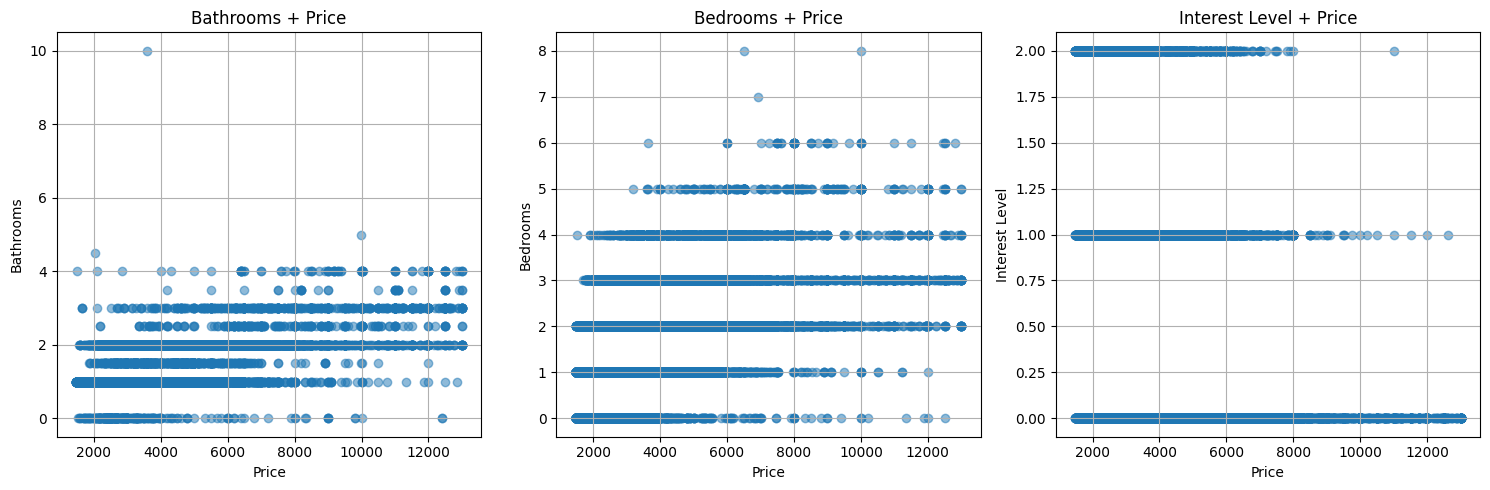

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(df_clean['price'], df_clean['bathrooms'], alpha=0.5)
axes[0].set_title('Bathrooms + Price', fontsize=12)
axes[0].set_xlabel('Price', fontsize=10)
axes[0].set_ylabel('Bathrooms', fontsize=10)
axes[0].grid(True)

axes[1].scatter(df_clean['price'], df_clean['bedrooms'], alpha=0.5)
axes[1].set_title('Bedrooms + Price', fontsize=12)
axes[1].set_xlabel('Price', fontsize=10)
axes[1].set_ylabel('Bedrooms', fontsize=10)
axes[1].grid(True)

axes[2].scatter(df_clean['price'], df_clean['interest_level'], alpha=0.5)
axes[2].set_title('Interest Level + Price', fontsize=12)
axes[2].set_xlabel('Price', fontsize=10)
axes[2].set_ylabel('Interest Level', fontsize=10)
axes[2].grid(True)

plt.tight_layout()
plt.show()

All 3 features show horizontal bands, indicating they are discrete variables rather than continuous.
High variance: For each feature value, there is substantial price variation (e.g., 1-bedroom apartments range from 1500 to 10000+). This suggests these features alone cannot accurately predict prices.
Weak linear relationships: While there is a general positive trend (more rooms/bedrooms -> higher price), the correlations are weak.
Interest level shows strong signal: It demonstrates the clearest separation, with 'high' (2) interest listings tending to have lower prices.

# 4. Creating Features

i.

In [22]:
df_clean['bathrooms_squared'] = df_clean['bathrooms'] ** 2
df_clean['bedrooms_squared'] = df_clean['bedrooms'] ** 2
df_clean['interest_level_squared'] = df_clean['interest_level'] ** 2
df_clean

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
4,1.00,1,1,2400,1.00,1,1
6,1.00,2,0,3800,1.00,4,0
9,1.00,2,1,3495,1.00,4,1
10,1.50,3,1,3000,2.25,9,1
15,1.00,0,0,2795,1.00,0,0
...,...,...,...,...,...,...,...
124000,1.00,3,0,2800,1.00,9,0
124002,1.00,2,1,2395,1.00,4,1
124004,1.00,1,1,1850,1.00,1,1
124008,1.00,2,1,4195,1.00,4,1


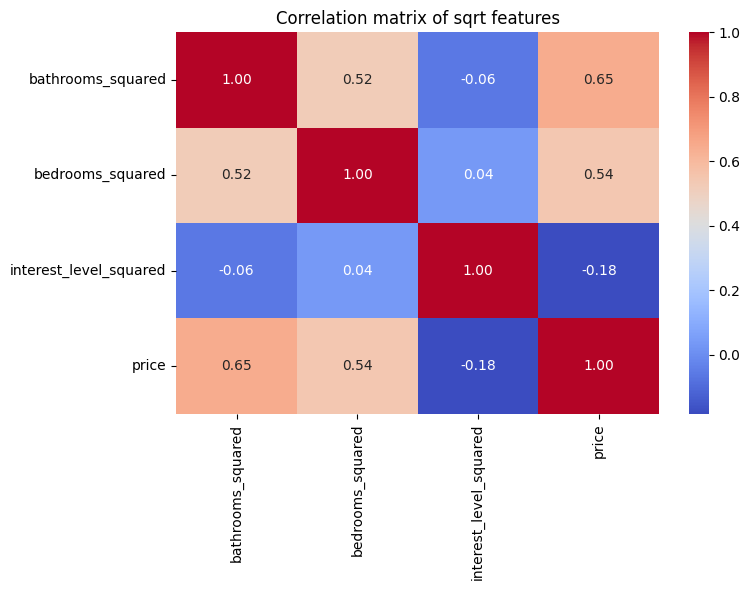

In [23]:
sqrtf = ['bathrooms_squared', 'bedrooms_squared', 'interest_level_squared', 'price']
corrr_matrix = df_clean[sqrtf].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corrr_matrix,annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix of sqrt features')
plt.tight_layout()
plt.show()

Answer: Nope, they correlated less than initial features. Sqrt operation does not reveal new hidden dependencies, however sometimes this operation helps to linear models to find more complex dependencies.

ii. - vi.

In [24]:
df_clean

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
4,1.00,1,1,2400,1.00,1,1
6,1.00,2,0,3800,1.00,4,0
9,1.00,2,1,3495,1.00,4,1
10,1.50,3,1,3000,2.25,9,1
15,1.00,0,0,2795,1.00,0,0
...,...,...,...,...,...,...,...
124000,1.00,3,0,2800,1.00,9,0
124002,1.00,2,1,2395,1.00,4,1
124004,1.00,1,1,1850,1.00,1,1
124008,1.00,2,1,4195,1.00,4,1


In [25]:
test = pd.read_json('data/test.json')

X_train, y_train = df_clean[['bathrooms', 'bedrooms']], df_clean['price'] 
test_clean = test[test['price'].between(lower_boundary, upper_boundary)].copy()
X_test, y_test = test_clean[['bathrooms', 'bedrooms']], test_clean['price']

poly = PolynomialFeatures(degree=10, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"Initial features num: {X_train.shape[1]}")
print(f"Preprocessed features num: {X_train_poly.shape[1]}")

Initial features num: 2
Preprocessed features num: 65


# 5. Training 3 models

i.

In [26]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

ii.

In [27]:
lr = LinearRegression()

lr.fit(X_train_poly, y_train)

y_train_pred_lr = lr.predict(X_train_poly)
y_test_pred_lr = lr.predict(X_test_poly)

df_clean['price_pred_lr'] = y_train_pred_lr
test_clean['price_pred_lr'] = y_test_pred_lr

mae_train_lr = mean_absolute_error(y_train, y_train_pred_lr)
mae_test_lr = mean_absolute_error(y_test, y_test_pred_lr)

rmse_train_lr = root_mean_squared_error(y_train, y_train_pred_lr)
rmse_test_lr = root_mean_squared_error(y_test, y_test_pred_lr)

result_MAE = pd.concat([result_MAE, pd.DataFrame({
    'model': ['linear_regression'],
    'train': [mae_train_lr],
    'test': [mae_test_lr]
})], ignore_index=True)

result_RMSE = pd.concat([result_RMSE, pd.DataFrame({
    'model': ['linear_regression'],
    'train': [rmse_train_lr],
    'test': [rmse_test_lr]
})], ignore_index=True)

print(f"Linear Regression - MAE: train={mae_train_lr:.2f}, test={mae_test_lr:.2f}")
print(f"Linear Regression - RMSE: train={rmse_train_lr:.2f}, test={rmse_test_lr:.2f}")

Linear Regression - MAE: train=756.04, test=14766524785508944.00
Linear Regression - RMSE: train=1077.57, test=3996657460343757824.00


C:\Users\pavel.zubkov\AppData\Local\Temp\ipykernel_21300\2391816719.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_MAE = pd.concat([result_MAE, pd.DataFrame({
C:\Users\pavel.zubkov\AppData\Local\Temp\ipykernel_21300\2391816719.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_RMSE = pd.concat([result_RMSE, pd.DataFrame({


iii.

In [28]:
dt = DecisionTreeRegressor(random_state=21)
dt.fit(X_train_poly, y_train)

y_train_pred_dt = dt.predict(X_train_poly)
y_test_pred_dt = dt.predict(X_test_poly)

df_clean['price_pred_dt'] = y_train_pred_dt
test_clean['price_pred_dt'] = y_test_pred_dt

mae_train_dt = mean_absolute_error(y_train, y_train_pred_dt)
mae_test_dt = mean_absolute_error(y_test, y_test_pred_dt)

rmse_train_dt = root_mean_squared_error(y_train, y_train_pred_dt)
rmse_test_rmse_dt = root_mean_squared_error(y_test, y_test_pred_dt)

result_MAE = pd.concat([result_MAE, pd.DataFrame({
    'model': ['decision_tree'],
    'train': [mae_train_dt],
    'test': [mae_test_dt]
})], ignore_index=True)

result_RMSE = pd.concat([result_RMSE, pd.DataFrame({
    'model': ['decision_tree'],
    'train': [rmse_train_dt],
    'test': [rmse_test_rmse_dt]
})], ignore_index=True)

print(f"Decision Tree - MAE: train={mae_train_dt:.2f}, test={mae_test_dt:.2f}")
print(f"Decision Tree - RMSE: train={rmse_train_dt:.2f}, test={rmse_test_rmse_dt:.2f}")

Decision Tree - MAE: train=756.04, test=759.64
Decision Tree - RMSE: train=1077.48, test=1081.29


iv.

In [29]:
mean_price = y_train.mean()

y_train_pred_mean = np.full(len(y_train), mean_price)
y_test_pred_mean = np.full(len(y_test), mean_price)

mae_train_mean = mean_absolute_error(y_train, y_train_pred_mean)
mae_test_mean = mean_absolute_error(y_test, y_test_pred_mean)

rmse_train_mean = root_mean_squared_error(y_train, y_train_pred_mean)
rmse_test_mean = root_mean_squared_error(y_test, y_test_pred_mean)

result_MAE = pd.concat([result_MAE, pd.DataFrame({
    'model': ['naive_mean'],
    'train': [mae_train_mean],
    'test': [mae_test_mean]
})], ignore_index=True)

result_RMSE = pd.concat([result_RMSE, pd.DataFrame({
    'model': ['naive_mean'],
    'train': [rmse_train_mean],
    'test': [rmse_test_mean]
})], ignore_index=True)

median_price = y_train.median()

y_train_pred_median = np.full(len(y_train), median_price)
y_test_pred_median = np.full(len(y_test), median_price)

mae_train_median = mean_absolute_error(y_train, y_train_pred_median)
mae_test_median = mean_absolute_error(y_test, y_test_pred_median)

rmse_train_median = root_mean_squared_error(y_train, y_train_pred_median)
rmse_test_median = root_mean_squared_error(y_test, y_test_pred_median)

result_MAE = pd.concat([result_MAE, pd.DataFrame({
    'model': ['naive_median'],
    'train': [mae_train_median],
    'test': [mae_test_median]
})], ignore_index=True)

result_RMSE = pd.concat([result_RMSE, pd.DataFrame({
    'model': ['naive_median'],
    'train': [rmse_train_median],
    'test': [rmse_test_median]
})], ignore_index=True)

print(f"Naive Mean - MAE: train={mae_train_mean:.2f}, test={mae_test_mean:.2f}")
print(f"Naive Median - MAE: train={mae_train_median:.2f}, test={mae_test_median:.2f}")

Naive Mean - MAE: train=1139.19, test=1137.83
Naive Median - MAE: train=1086.21, test=1084.59


v.

In [30]:
best_model_mae = result_MAE.loc[result_MAE['test'].idxmin(), 'model']
best_model_rmse = result_RMSE.loc[result_RMSE['test'].idxmin(), 'model']

print(f"Best model by MAE: {best_model_mae}")
print(f"Best model by RMSE: {best_model_rmse}")

Best model by MAE: decision_tree
Best model by RMSE: decision_tree


In [31]:
print('All models by MAE:')
result_MAE.sort_values(by='test')

All models by MAE:


,model,train,test
1,decision_tree,756.04,759.64
3,naive_median,1086.21,1084.59
2,naive_mean,1139.19,1137.83
0,linear_regression,756.04,14766524785508944.00


In [32]:
print('All models by RMSE:')
result_RMSE.sort_values(by='test')

All models by RMSE:


,model,train,test
1,decision_tree,1077.48,1081.29
2,naive_mean,1597.65,1590.39
3,naive_median,1644.24,1635.40
0,linear_regression,1077.57,3996657460343757824.00


Conclusion

Overall, the results are comparable and similar to the benchmarks. The anomalous value on the LinReg test dataset can be explained by the peculiarity of the polynomial function for this model, and this clearly demonstrates how the type of preprocessing of the dataset's features can ultimately influence the metrics (the test dataset likely has larger feature values ​​than the training dataset, causing the test data to increase sharply upon extrapolation).